In [60]:
from datetime import datetime

etherpad_url = "http://localhost:9001/"
search_query = f"{datetime.now().strftime('%Y%m%d%H%M%s')}"
test_content = f"{search_query} searchable content for E2E testing"
default_result_path = None
close_on_fail = False
transition_timeout = 10000

In [61]:
search_query

'2025103111041761876241'

In [62]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpdh4qxxzz'

# ep_search E2E Test - Basic Search

Test that the search functionality is accessible and returns results.

In [63]:
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20251031-110401',
 '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpexa5b0cv')

## Step 1: Create a pad with searchable content

Start epoch: 1761876241.8920588 seconds


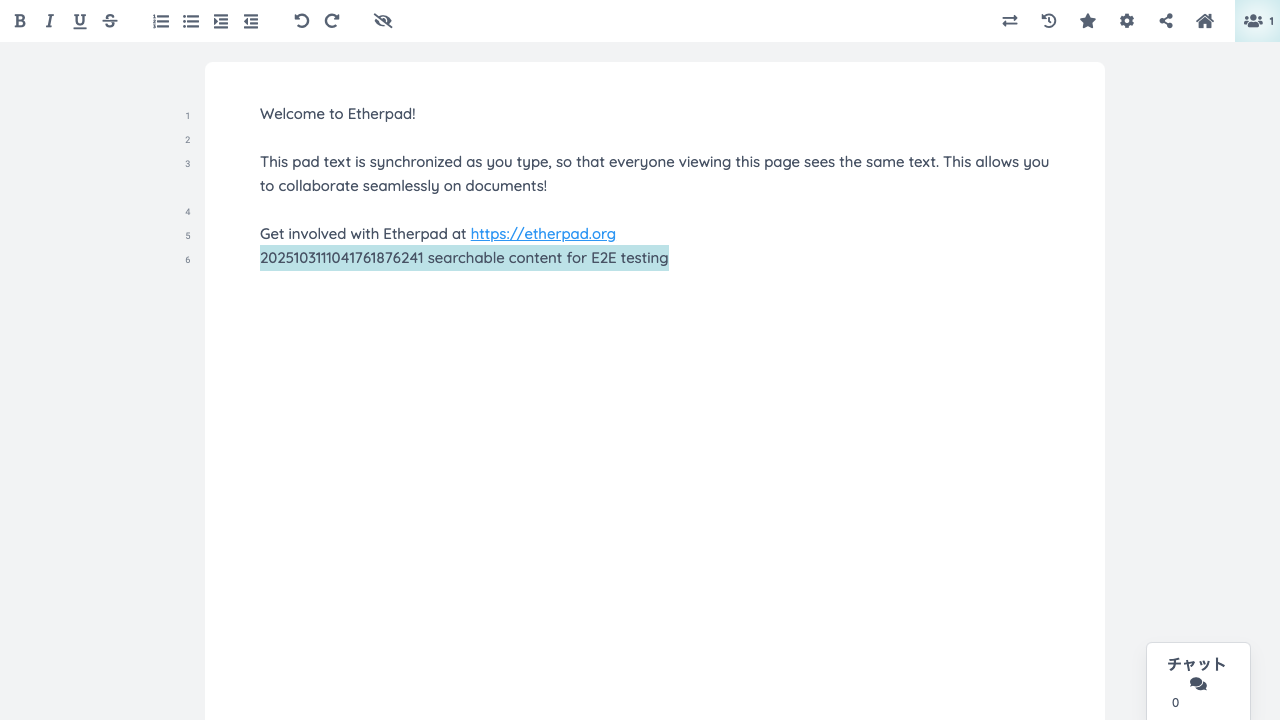

In [64]:
import time

pad_id = f"test-search-{int(time.time())}"

async def _step(page):
    await page.goto(f"{etherpad_url}p/{pad_id}")
    
    # Wait for editor to load
    await expect(page.locator('iframe[name="ace_outer"]')).to_be_visible(timeout=transition_timeout)
    
    # Get iframe and add content
    iframe_locator = page.frame_locator('iframe[name="ace_outer"]').frame_locator('iframe[name="ace_inner"]')
    editor = iframe_locator.locator('#innerdocbody')
    await expect(editor).to_be_visible(timeout=transition_timeout)
    
    await editor.click()
    await editor.press_sequentially(test_content)
    
    # Wait for save and indexing
    await page.wait_for_timeout(3000)
    
await run_pw(_step)

## Step 2: Navigate to search page and verify UI elements exist

Start epoch: 1761876246.3697028 seconds


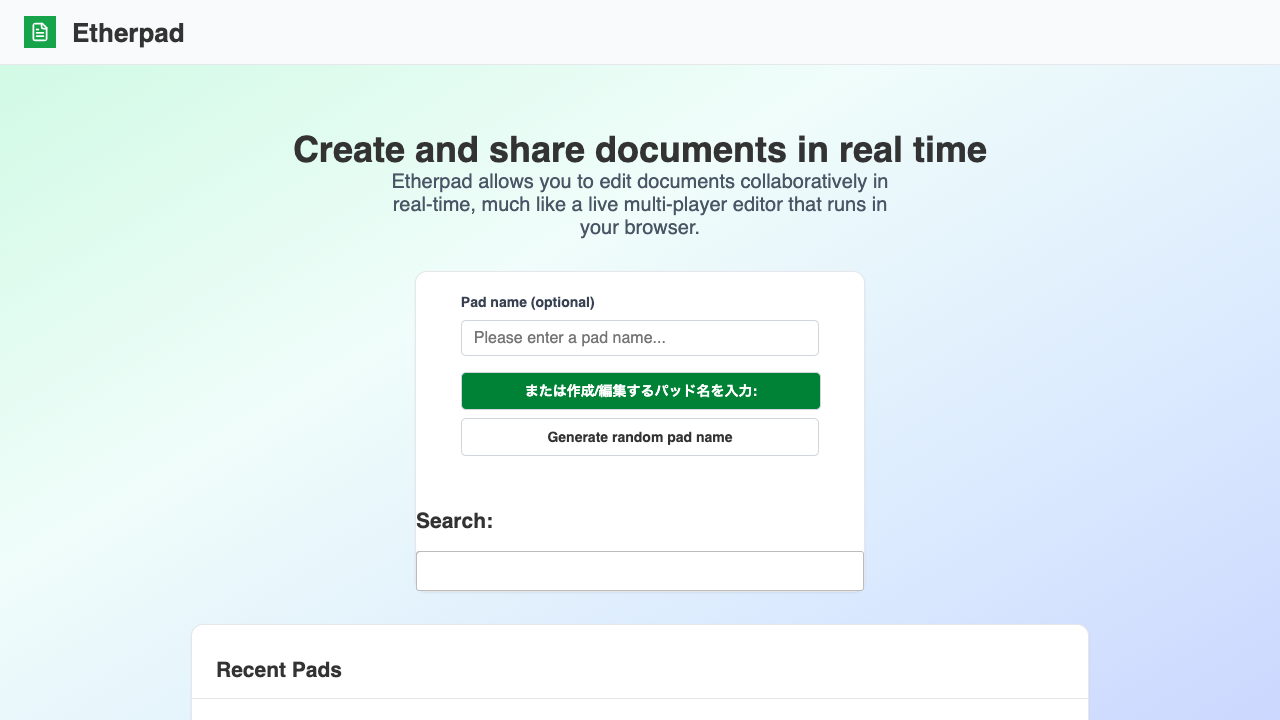

In [65]:
async def _step(page):
    await page.goto(f"{etherpad_url}")
    
    # Verify search form elements exist
    await expect(page.locator('#searchInput')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#searchForm')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('#searchResults')).to_be_hidden(timeout=transition_timeout)
    
await run_pw(_step)

## Step 3: Perform search and verify results appear

Start epoch: 1761876246.650384 seconds


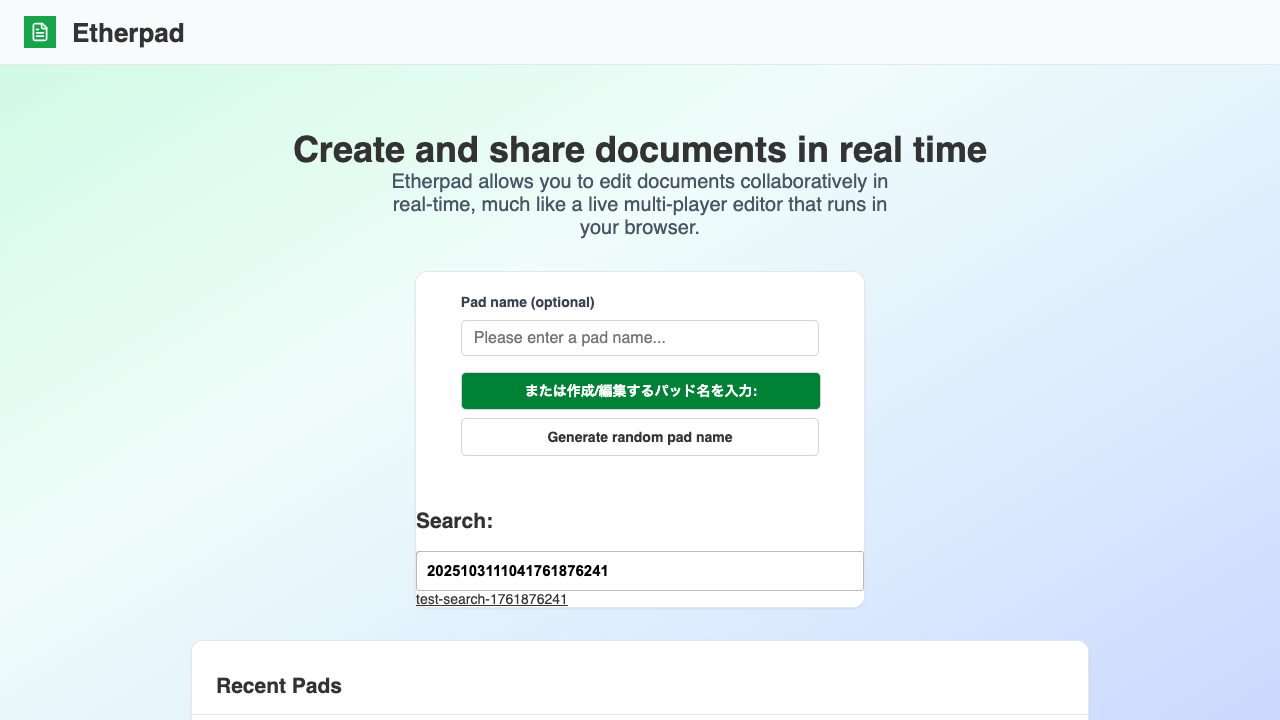

In [66]:
async def _step(page):
    # Fill and submit search
    await page.locator('#searchInput').fill(search_query)
    await page.keyboard.press('Enter')
    
    # Wait for AJAX request to complete
    await page.wait_for_timeout(2000)
    
    # Verify that results div has content
    # The search should return results (at minimum, it should process the query)
    results_div = page.locator('#searchResults')
    
    # Results exist - verify they contain proper links
    await expect(results_div.locator('a')).to_have_count(count=1, timeout=5000)
    
await run_pw(_step)

## Cleanup

In [67]:
await finish_pw_context(screenshot=True, last_path=default_result_path)

Screenshot: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpdh4qxxzz/last-screenshot.png
Video: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpdh4qxxzz/video-1.webm
HAR: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpdh4qxxzz/har.zip


スクリーンキャプチャ動画の取得に失敗しました。
Traceback (most recent call last):
  File "/Users/yazawa/workspace/nii-cloud/ep_search/tests/e2e/notebooks/scripts/playwright.py", line 202, in _finish_pw_context
    shutil.copyfile(video_path, dest_video_path)
  File "/Users/yazawa/.pyenv/versions/3.11.5/lib/python3.11/shutil.py", line 256, in copyfile
    with open(src, 'rb') as fsrc:
         ^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpexa5b0cv/videos/284fe578f141454ba023bf0d808ea688.webm'


In [68]:
!rm -rf {work_dir}